# 02 Objective Windows
Explore the objective-window table: outcome distributions, setup profiles, feature correlations with securing the objective.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from lolobj.config import PROCESSED_DIR

parquet_path = PROCESSED_DIR / 'objective_windows.parquet'
df = pd.read_parquet(parquet_path)
print(f'Loaded {len(df)} rows, {df["match_id"].nunique()} matches')
df.head(3)

Loaded 1872 rows, 474 matches


,match_id,objective_instance,objective_type,objective_number,objective_time_ms,team_id,team_side,rank_bucket,patch,team_alive_T_30,...,gold_diff_T_60,gold_diff_T_30,jungler_level_diff_T_60,wards_placed_120s,wards_killed_120s,previous_dragons_team,previous_dragons_enemy,secured,outcome_label,net_value
0,EUW1_7519033568,dragon_1,DRAGON,1,879233,100,blue,unknown,15.17.708.5788,5,...,2712,3333,1,4,0,0,0,1,coinflip,3
1,EUW1_7519033568,dragon_1,DRAGON,1,879233,200,red,mid,15.17.708.5788,5,...,-2712,-3333,-1,4,2,0,0,0,throw_setup,-5
2,EUW1_7519033568,dragon_2,DRAGON,2,1203382,100,blue,unknown,15.17.708.5788,4,...,2026,2026,0,1,1,1,0,1,lost_fight_got_objective,2


## 1. Outcome label distribution

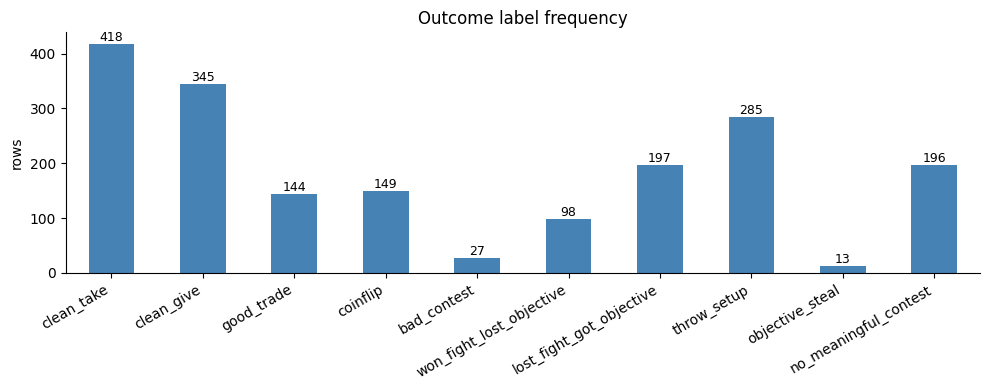

outcome_label
clean_take                  418
clean_give                  345
good_trade                  144
coinflip                    149
bad_contest                  27
won_fight_lost_objective     98
lost_fight_got_objective    197
throw_setup                 285
objective_steal              13
no_meaningful_contest       196


In [2]:
OUTCOME_ORDER = [
    'clean_take', 'clean_give', 'good_trade', 'coinflip',
    'bad_contest', 'won_fight_lost_objective', 'lost_fight_got_objective',
    'throw_setup', 'objective_steal', 'no_meaningful_contest',
]

counts = df['outcome_label'].value_counts().reindex(OUTCOME_ORDER).dropna()
ax = counts.plot(kind='bar', color='steelblue')
ax.set_title('Outcome label frequency')
ax.set_ylabel('rows')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(counts.to_string())

## 2. Setup profiles

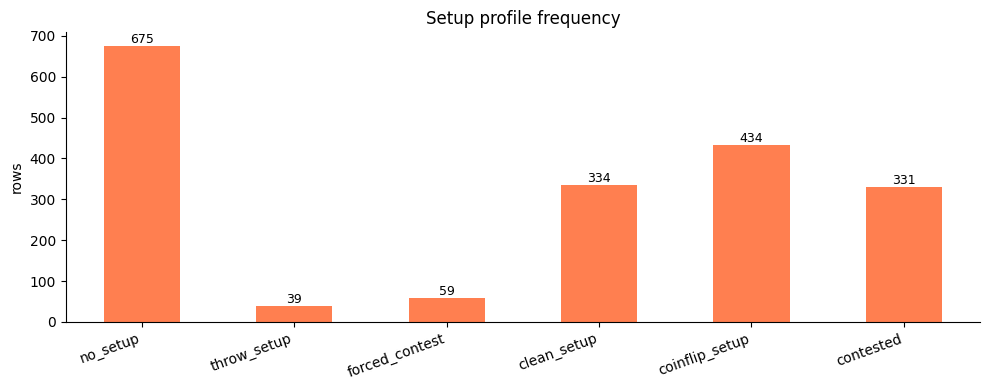

In [3]:
from lolobj.analysis.baseline_report import assign_setup_profiles

df['setup_profile'] = assign_setup_profiles(df)

profile_order = ['no_setup', 'throw_setup', 'forced_contest', 'clean_setup', 'coinflip_setup', 'contested']
pcounts = df['setup_profile'].value_counts().reindex(profile_order).dropna()

ax = pcounts.plot(kind='bar', color='coral')
ax.set_title('Setup profile frequency')
ax.set_ylabel('rows')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Secure rate by setup profile

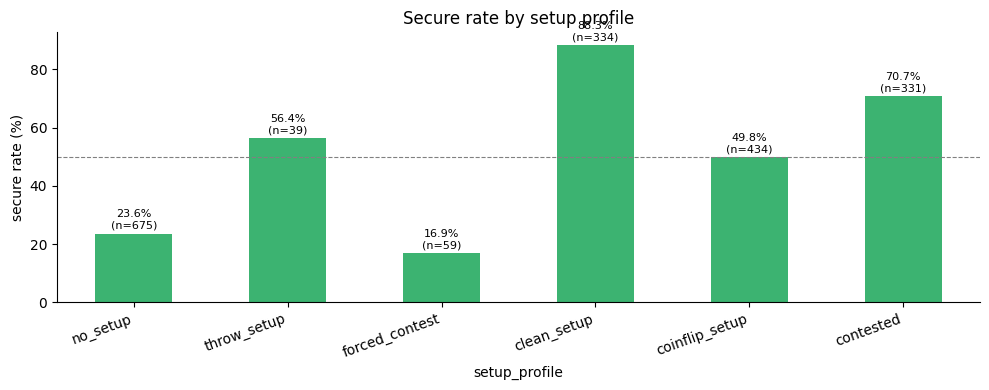

In [4]:
secure_by_profile = (
    df.groupby('setup_profile')['secured']
    .agg(['mean', 'count'])
    .reindex(profile_order)
    .dropna()
    .rename(columns={'mean': 'secure_rate', 'count': 'n'})
)
secure_by_profile['secure_rate_pct'] = (secure_by_profile['secure_rate'] * 100).round(1)

ax = secure_by_profile['secure_rate_pct'].plot(kind='bar', color='mediumseagreen')
ax.set_title('Secure rate by setup profile')
ax.set_ylabel('secure rate (%)')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(rotation=20, ha='right')
for i, (rate, n) in enumerate(zip(secure_by_profile['secure_rate_pct'], secure_by_profile['n'])):
    ax.annotate(f'{rate}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Key binary feature secure rates

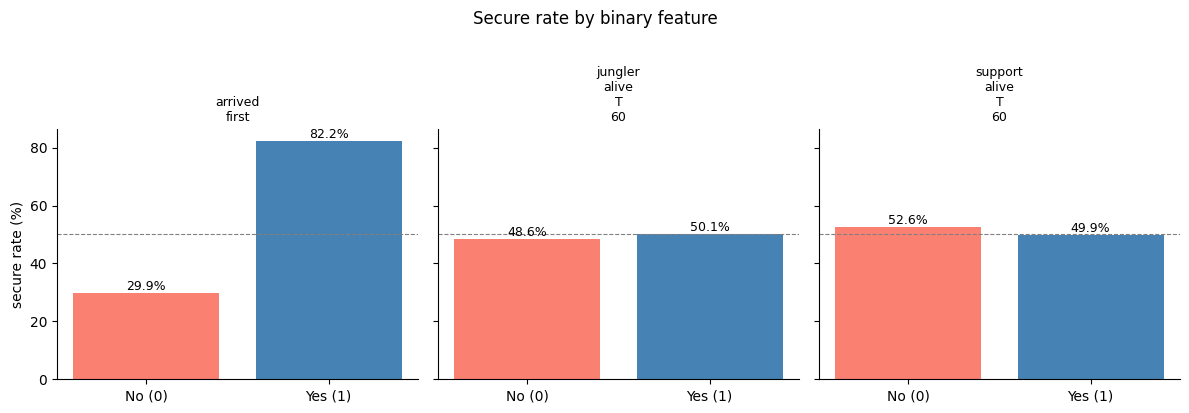

In [5]:
binary_features = [
    'arrived_first',
    'jungler_alive_T_60',
    'support_alive_T_60',
]

fig, axes = plt.subplots(1, len(binary_features), figsize=(12, 4), sharey=True)
for ax, feat in zip(axes, binary_features):
    rates = df.groupby(feat)['secured'].mean() * 100
    bars = ax.bar(['No (0)', 'Yes (1)'], [rates.get(0, 0), rates.get(1, 0)],
                   color=['salmon', 'steelblue'])
    ax.set_title(feat.replace('_', '\n'), fontsize=9)
    ax.set_ylabel('secure rate (%)' if ax == axes[0] else '')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, [rates.get(0, 0), rates.get(1, 0)]):
        ax.annotate(f'{val:.1f}%', (bar.get_x() + bar.get_width()/2, val + 1),
                    ha='center', fontsize=9)
plt.suptitle('Secure rate by binary feature', y=1.02)
plt.tight_layout()
plt.show()

## 5. Deaths before objective vs secure rate

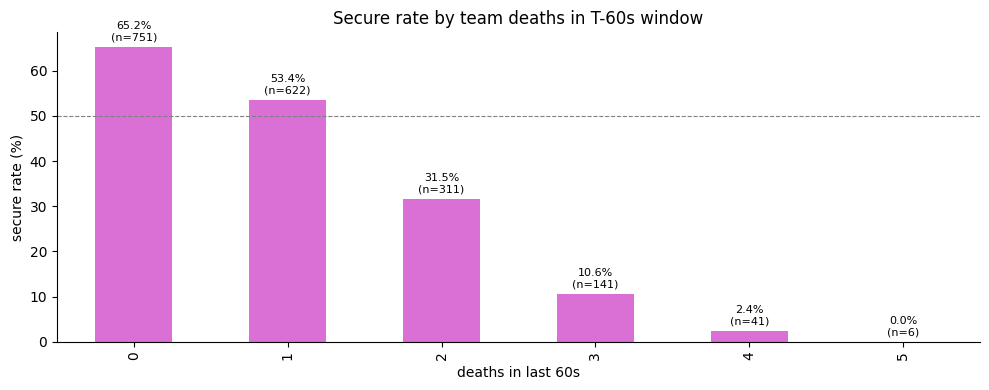

In [6]:
death_secure = df.groupby('team_deaths_60s')['secured'].agg(['mean', 'count'])
death_secure.columns = ['secure_rate', 'n']
death_secure['secure_rate_pct'] = (death_secure['secure_rate'] * 100).round(1)

ax = death_secure['secure_rate_pct'].plot(kind='bar', color='orchid')
ax.set_title('Secure rate by team deaths in T-60s window')
ax.set_xlabel('deaths in last 60s')
ax.set_ylabel('secure rate (%)')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
for i, (rate, n) in enumerate(zip(death_secure['secure_rate_pct'], death_secure['n'])):
    ax.annotate(f'{rate}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 6. Gold diff at T-30 vs secure rate

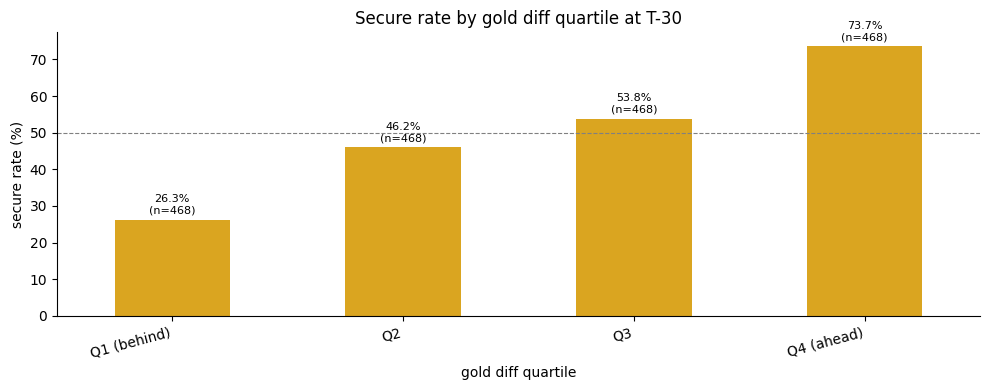

In [7]:
# Bin gold_diff_T_30 into quartiles
df['gold_diff_bin'] = pd.qcut(df['gold_diff_T_30'], q=4,
                               labels=['Q1 (behind)', 'Q2', 'Q3', 'Q4 (ahead)'])
gold_secure = df.groupby('gold_diff_bin', observed=True)['secured'].agg(['mean', 'count'])
gold_secure.columns = ['secure_rate', 'n']

ax = (gold_secure['secure_rate'] * 100).plot(kind='bar', color='goldenrod')
ax.set_title('Secure rate by gold diff quartile at T-30')
ax.set_xlabel('gold diff quartile')
ax.set_ylabel('secure rate (%)')
ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(rotation=15, ha='right')
for i, (rate, n) in enumerate(zip(gold_secure['secure_rate'] * 100, gold_secure['n'])):
    ax.annotate(f'{rate:.1f}%\n(n={n})', (i, rate + 1), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 7. Feature correlation with `secured`

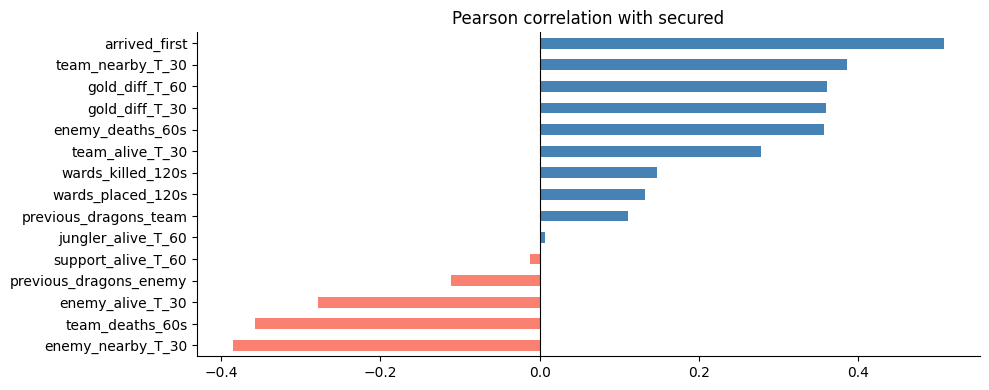

enemy_nearby_T_30        -0.386
team_deaths_60s          -0.357
enemy_alive_T_30         -0.278
previous_dragons_enemy   -0.112
support_alive_T_60       -0.012
jungler_alive_T_60        0.007
previous_dragons_team     0.112
wards_placed_120s         0.132
wards_killed_120s         0.148
team_alive_T_30           0.278
enemy_deaths_60s          0.357
gold_diff_T_30            0.360
gold_diff_T_60            0.361
team_nearby_T_30          0.386
arrived_first             0.509


In [8]:
numeric_features = [
    'arrived_first', 'jungler_alive_T_60', 'support_alive_T_60',
    'team_alive_T_30', 'enemy_alive_T_30',
    'team_nearby_T_30', 'enemy_nearby_T_30',
    'team_deaths_60s', 'enemy_deaths_60s',
    'gold_diff_T_30', 'gold_diff_T_60',
    'wards_placed_120s', 'wards_killed_120s',
    'previous_dragons_team', 'previous_dragons_enemy',
]

corr = df[numeric_features + ['secured']].corr()['secured'].drop('secured').sort_values()

colors = ['salmon' if v < 0 else 'steelblue' for v in corr]
ax = corr.plot(kind='barh', color=colors)
ax.set_title('Pearson correlation with secured')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr.round(3).to_string())

## 8. Dragon 1 vs Dragon 2 comparison

In [9]:
for num in [1, 2]:
    sub = df[df['objective_number'] == num]
    print(f'--- Dragon {num} (n={len(sub)}) ---')
    print(sub['outcome_label'].value_counts().to_string())
    print(f'  secure rate     : {sub["secured"].mean():.1%}')
    print(f'  arrived_first   : {sub["arrived_first"].mean():.1%}')
    print(f'  avg gold_diff_30: {sub["gold_diff_T_30"].mean():.0f}')
    print()

--- Dragon 1 (n=948) ---
outcome_label
clean_take                  207
clean_give                  201
lost_fight_got_objective    120
throw_setup                 115
no_meaningful_contest       100
good_trade                   72
coinflip                     65
won_fight_lost_objective     47
bad_contest                  17
objective_steal               4
  secure rate     : 50.0%
  arrived_first   : 39.5%
  avg gold_diff_30: 0

--- Dragon 2 (n=924) ---
outcome_label
clean_take                  211
throw_setup                 170
clean_give                  144
no_meaningful_contest        96
coinflip                     84
lost_fight_got_objective     77
good_trade                   72
won_fight_lost_objective     51
bad_contest                  10
objective_steal               9
  secure rate     : 50.0%
  arrived_first   : 37.3%
  avg gold_diff_30: 0



## 9. Rank breakdown (populated after full seed)

Rank distribution:
rank_bucket
unknown    998
elite      266
mid        228
high       193
low        187


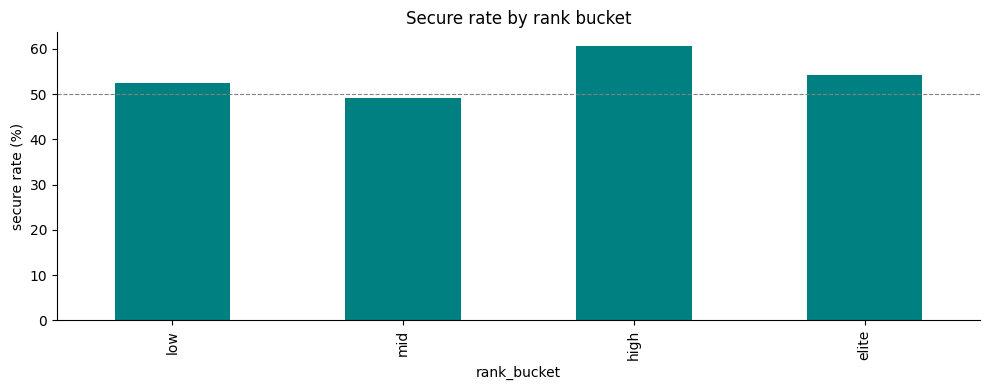

In [10]:
rank_counts = df['rank_bucket'].value_counts()
print('Rank distribution:')
print(rank_counts.to_string())

if set(df['rank_bucket'].unique()) - {'unknown'}:
    rank_secure = df.groupby('rank_bucket')['secured'].mean() * 100
    ax = rank_secure.reindex(['low','mid','high','elite']).dropna().plot(kind='bar', color='teal')
    ax.set_title('Secure rate by rank bucket')
    ax.set_ylabel('secure rate (%)')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print('All rows are rank=unknown — run seed_matches then rebuild the parquet to populate rank.')

## 10. Full baseline report (text)

In [11]:
from lolobj.analysis.baseline_report import run_report
run_report(parquet_path)


Loaded 1872 rows from C:\Users\Laser\dig-baron\data\processed\objective_windows.parquet
Columns: ['match_id', 'objective_instance', 'objective_type', 'objective_number', 'objective_time_ms', 'team_id', 'team_side', 'rank_bucket', 'patch', 'team_alive_T_30', 'enemy_alive_T_30', 'jungler_alive_T_60', 'support_alive_T_60', 'team_deaths_30s', 'team_deaths_60s', 'team_deaths_90s', 'enemy_deaths_60s', 'team_nearby_T_90', 'team_nearby_T_60', 'team_nearby_T_30', 'enemy_nearby_T_30', 'jungler_dist_T_60', 'support_dist_T_60', 'mid_dist_T_60', 'arrived_first', 'gold_diff_T_60', 'gold_diff_T_30', 'jungler_level_diff_T_60', 'wards_placed_120s', 'wards_killed_120s', 'previous_dragons_team', 'previous_dragons_enemy', 'secured', 'outcome_label', 'net_value']
Rank buckets present: ['elite', 'high', 'low', 'mid', 'unknown']
Objectives: {('DRAGON', 1): np.int64(948), ('DRAGON', 2): np.int64(924)}

SECTION 1: Outcome Label Frequencies

Overall (n=1872 rows)
+----------------------------+--------+--------